Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Đang tiền xử lý dữ liệu...
🔍 Đang tìm số cụm tối ưu...


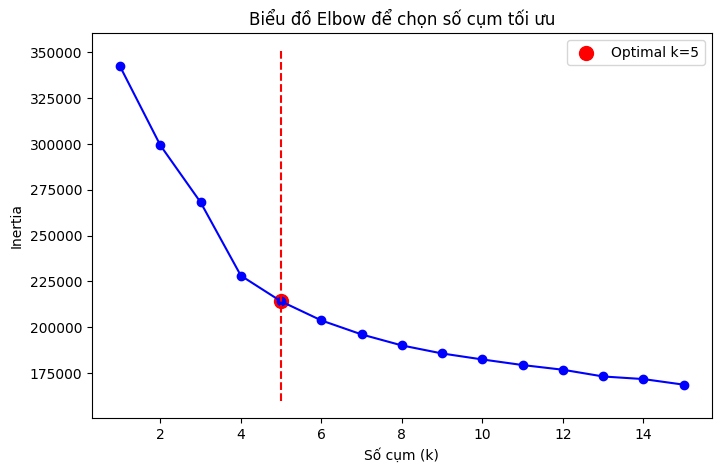

✅ Số cụm tối ưu được xác định: 5
📊 Đang phân cụm khách hàng với 5 cụm...
🔍 Phân tích kết quả phân cụm...
📝 Đã loại bỏ 1 outliers trong cụm 4 theo cột 'Time_taken (min)'


Delivery_Distance_km          Order_Hour            Time_taken (min)  \
                        mean      std       mean <lambda_0>             mean   
Cluster                                                                        
0                      12.37    53.79      20.09         22            20.90   
1                       4.71    21.43      10.60         12            21.39   
2                      13.42    56.88      18.23         21            36.89   
3                      12.48    24.61      18.46         19            36.52   
4                    5183.07  1034.87      17.09         23            25.07   

               Type_of_order           City Road_traffic_density  \
        median      <lambda>       <lambda>             <lambda>   
Cluster                                                            
0         21.0         Snack  Metropolitian                  Low   
1         21.0          Meal  Metropolitian                  Low   
2         36.0          Meal  Metropolitian                  Jam   
3         36.0         Snack  Metropolitian                  Jam   
4         25.0        Buffet  Metropolitian                  Low   

        Weather_conditions Weekend Delivery_person_Ratings  
                  <lambda>    mean                    mean  
Cluster                                                     
0                    Sunny    0.28                    4.74  
1                    Sunny    0.27                    4.71  
2                      Fog    0.27                    4.04  
3                      Fog    0.27                    4.74  
4               Sandstorms    0.25                    4.63

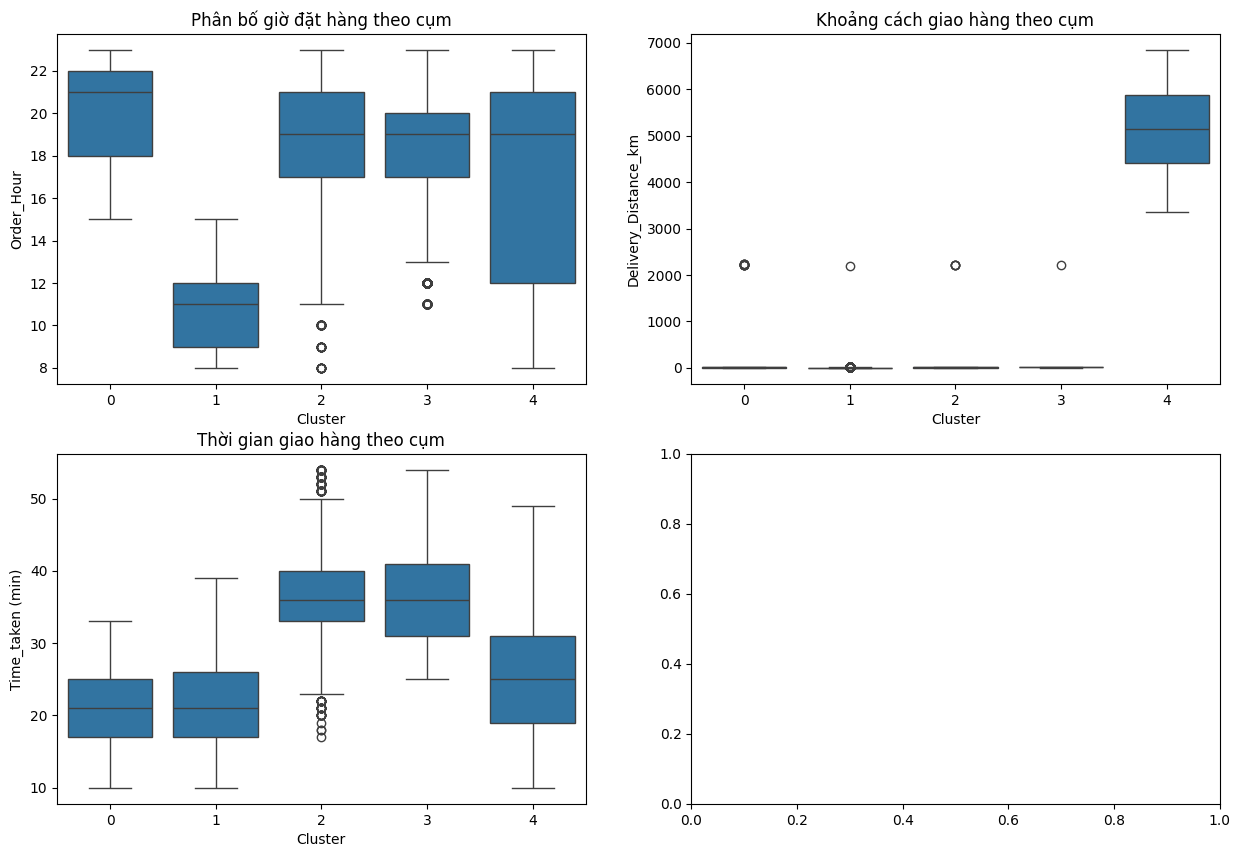

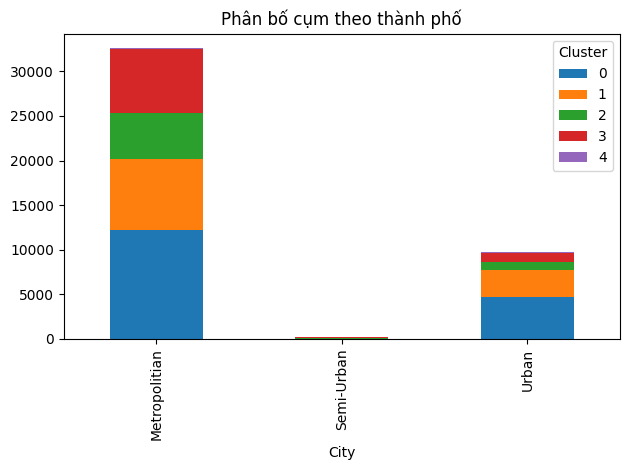

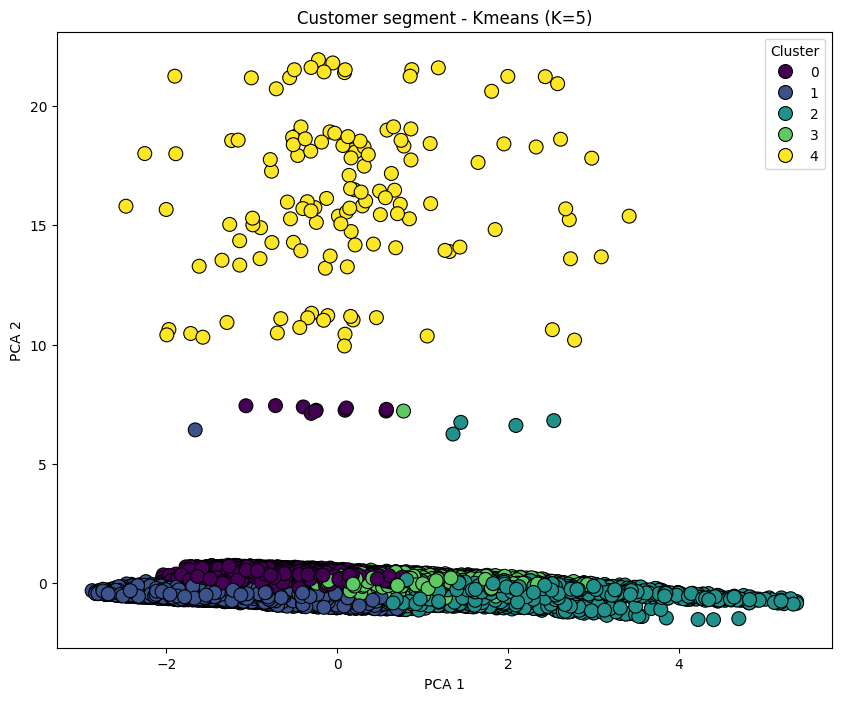

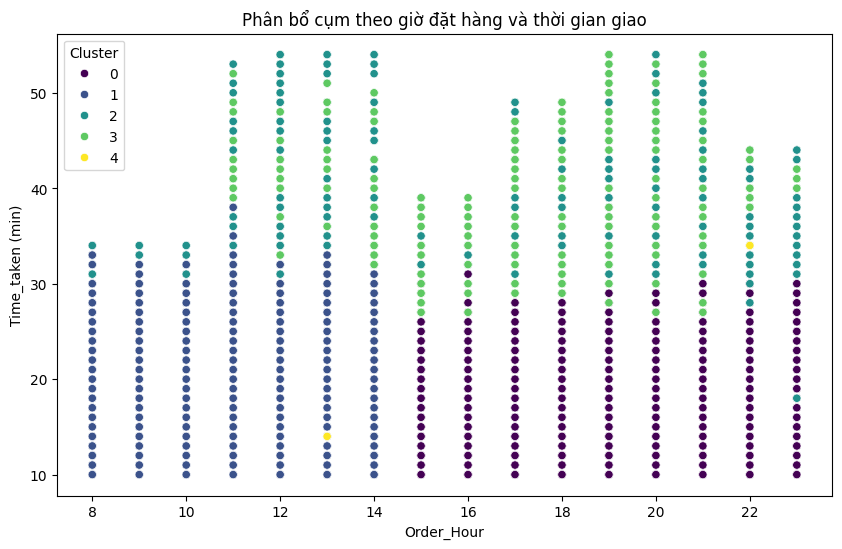

✅ Đã xuất kết quả lên Google Sheet: https://docs.google.com/spreadsheets/d/1NICu2t3xaNgn3LVboJQA2PtElPV3RxIbOHF86mkg5jw


In [ ]:
# CÀI ĐẶT THƯ VIỆN
!pip install -q scikit-learn pandas matplotlib seaborn kneed

import pandas as pd
import numpy as np
from geopy.distance import geodesic
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
from kneed import KneeLocator
from sklearn.decomposition import PCA

import warnings
import gspread
from google.colab import drive
from gspread_dataframe import set_with_dataframe
from google.colab import auth
from google.auth import default

# CẤU HÌNH
warnings.filterwarnings('ignore')
drive.mount('/content/drive')

# Google Authentication:
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# LOAD VÀ TIỀN XỬ LÝ DỮ LIỆU
df = pd.read_excel('/content/drive/My Drive/Colab Notebooks/Zomato Dataset.xlsx')

## 1. Tiền xử lý dữ liệu
def preprocess_data(df):
    df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')
    df = df.dropna(subset=['Order_Date'])

    def parse_time(time_str):
        try:
            if isinstance(time_str, str) and len(time_str.split(':')) == 3:
                return pd.to_datetime(time_str, format='%H:%M:%S').time()
            elif isinstance(time_str, str) and len(time_str.split(':')) == 2:
                return pd.to_datetime(time_str, format='%H:%M').time()
            else:
                return pd.to_datetime('12:00', format='%H:%M').time()
        except:
            return pd.to_datetime('12:00', format='%H:%M').time()

    df['Order_Time'] = df['Time_Orderd'].apply(parse_time)
    df['Order_Hour'] = df['Order_Time'].apply(lambda x: x.hour)

    def calc_distance(row):
        try:
            return geodesic(
                (row['Restaurant_latitude'], row['Restaurant_longitude']),
                (row['Delivery_location_latitude'], row['Delivery_location_longitude'])
            ).km
        except:
            return np.nan

    df['Delivery_Distance_km'] = df.apply(calc_distance, axis=1)
    df['Weekend'] = df['Order_Date'].dt.weekday >= 5
    df['Month'] = df['Order_Date'].dt.month

    df = df.dropna(subset=[
        'Delivery_Distance_km', 'Time_taken (min)', 'Type_of_order',
        'Type_of_vehicle', 'Road_traffic_density', 'Weather_conditions',
        'City', 'Delivery_person_Ratings'
    ])

    # Chọn các features
    features = df[[
        'Delivery_Distance_km', 'Order_Hour', 'Time_taken (min)', 'Type_of_order',
        'Type_of_vehicle', 'Road_traffic_density', 'Weather_conditions', 'City',
        'Weekend', 'Month', 'Delivery_person_Ratings',
        'Delivery_location_latitude', 'Delivery_location_longitude'
    ]].copy()

    return features

def find_optimal_clusters(data, max_clusters=15):
    numeric_features = ['Delivery_Distance_km', 'Order_Hour', 'Time_taken (min)', 'Delivery_person_Ratings']
    categorical_features = ['Type_of_order', 'Type_of_vehicle', 'Road_traffic_density',
                            'Weather_conditions', 'City', 'Weekend', 'Month']

    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

    X_processed = preprocessor.fit_transform(data)

    inertia_list = []
    cluster_range = range(1, max_clusters + 1)

    for k in cluster_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_processed)
        inertia_list.append(kmeans.inertia_)

    # Xác định elbow
    kl = KneeLocator(cluster_range, inertia_list, curve='convex', direction='decreasing')
    optimal_k = kl.elbow

    # Vẽ biểu đồ Elbow
    plt.figure(figsize=(8,5))
    plt.plot(cluster_range, inertia_list, 'bo-')
    if optimal_k is not None:
        plt.vlines(optimal_k, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='red')
        plt.scatter(optimal_k, inertia_list[optimal_k-1], c='red', s=100, label=f'Optimal k={optimal_k}')
    plt.xlabel('Số cụm (k)')
    plt.ylabel('Inertia')
    plt.title('Biểu đồ Elbow để chọn số cụm tối ưu')
    plt.legend()
    plt.show()

    print(f"✅ Số cụm tối ưu được xác định: {optimal_k}")
    return optimal_k

## 2. Phân cụm
def perform_clustering(data, optimal_k):
    numeric_features = ['Delivery_Distance_km', 'Order_Hour', 'Time_taken (min)', 'Delivery_person_Ratings']
    categorical_features = ['Type_of_order', 'Type_of_vehicle', 'Road_traffic_density',
                            'Weather_conditions', 'City', 'Weekend', 'Month']

    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('cluster', KMeans(n_clusters=optimal_k, random_state=42, n_init=10))
    ])

    processed_data = data.copy()
    processed_data['Cluster'] = pipeline.fit_predict(data)

    return processed_data, preprocessor, pipeline

## 3. Phân tích kết quả
def analyze_clusters(clustered_data):
    def remove_outliers_iqr(df, column, cluster_label):
        Q1 = df.loc[df['Cluster'] == cluster_label, column].quantile(0.25)
        Q3 = df.loc[df['Cluster'] == cluster_label, column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        filtered_df = df[~((df['Cluster'] == cluster_label) & ((df[column] < lower_bound) | (df[column] > upper_bound)))]
        print(f"📝 Đã loại bỏ {len(df) - len(filtered_df)} outliers trong cụm {cluster_label} theo cột '{column}'")
        return filtered_df

    clustered_data = remove_outliers_iqr(clustered_data, 'Time_taken (min)', cluster_label=4)

    cluster_profile = clustered_data.groupby('Cluster').agg({
        'Delivery_Distance_km': ['mean', 'std'],
        'Order_Hour': ['mean', lambda x: pd.Series.mode(x)[0]],
        'Time_taken (min)': ['mean', 'median'],
        'Type_of_order': lambda x: x.mode().iloc[0],
        'City': lambda x: x.mode().iloc[0],
        'Road_traffic_density': lambda x: x.mode().iloc[0],
        'Weather_conditions': lambda x: x.mode().iloc[0],
        'Weekend': 'mean',
        'Delivery_person_Ratings': 'mean'
    }).round(2)

    display(cluster_profile)

    # Visualization
    plt.figure(figsize=(15, 10))
    plt.subplot(2, 2, 1)
    sns.boxplot(x='Cluster', y='Order_Hour', data=clustered_data)
    plt.title('Phân bố giờ đặt hàng theo cụm')

    plt.subplot(2, 2, 2)
    sns.boxplot(x='Cluster', y='Delivery_Distance_km', data=clustered_data)
    plt.title('Khoảng cách giao hàng theo cụm')

    plt.subplot(2, 2, 3)
    sns.boxplot(x='Cluster', y='Time_taken (min)', data=clustered_data)
    plt.title('Thời gian giao hàng theo cụm')

    plt.subplot(2, 2, 4)
    pd.crosstab(clustered_data['City'], clustered_data['Cluster']).plot(kind='bar', stacked=True)
    plt.title('Phân bố cụm theo thành phố')
    plt.tight_layout()
    plt.show()

    # Bản đồ cụm
    fig = px.density_mapbox(
        clustered_data,
        lat='Delivery_location_latitude',
        lon='Delivery_location_longitude',
        z='Cluster',
        radius=10,
        center=dict(lat=clustered_data['Delivery_location_latitude'].mean(),
                    lon=clustered_data['Delivery_location_longitude'].mean()),
        zoom=10,
        mapbox_style="stamen-terrain",
        title='Bản đồ phân cụm khách hàng',
        hover_data=['City', 'Type_of_order']
    )
    fig.show()
# HÀM VẼ PCA
def plot_pca_2d_scatter(clustered_data, preprocessor, n_clusters=5):
    numeric_features = ['Delivery_Distance_km', 'Order_Hour', 'Time_taken (min)', 'Delivery_person_Ratings']
    categorical_features = ['Type_of_order', 'Type_of_vehicle', 'Road_traffic_density',
                            'Weather_conditions', 'City', 'Weekend', 'Month']

    X = clustered_data[numeric_features + categorical_features]
    X_processed = preprocessor.transform(X)

    pca = PCA(n_components=2)
    pca_components = pca.fit_transform(X_processed)

    clustered_data['PCA1'] = pca_components[:, 0]
    clustered_data['PCA2'] = pca_components[:, 1]

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=clustered_data, palette='viridis', s=100, edgecolor='k')
    plt.title(f'Customer segment - Kmeans (K={n_clusters})')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.legend(title='Cluster')
    plt.show()

# HÀM EXPORT GOOGLE SHEET
def export_to_google_sheet(data, sheet_name='Ket_qua_phan_khach_hang'):
    sh = gc.create(sheet_name)
    worksheet1 = sh.add_worksheet(title='Chi_tiet_cac_don_hang', rows=data.shape[0]+1, cols=data.shape[1]+1)
    set_with_dataframe(worksheet1, data)
    print(f"✅ Đã xuất kết quả lên Google Sheet: {sh.url}")

# MAIN
df = pd.read_excel('/content/drive/My Drive/Colab Notebooks/Zomato Dataset.xlsx')

def main():
    print("🔄 Đang tiền xử lý dữ liệu...")
    processed_data = preprocess_data(df)

    print("🔍 Đang tìm số cụm tối ưu...")
    optimal_k = find_optimal_clusters(processed_data)

    print(f"📊 Đang phân cụm khách hàng với {optimal_k} cụm...")
    clustered_data, preprocessor, model = perform_clustering(processed_data, optimal_k)

    print("🔍 Phân tích kết quả phân cụm...")
    analyze_clusters(clustered_data)

    return clustered_data, preprocessor, optimal_k

# 👉 GỌI MAIN
final_result, preprocessor, optimal_k = main()

# 👉 VẼ PCA
plot_pca_2d_scatter(final_result, preprocessor, n_clusters=optimal_k)

# 👉 SCATTER GIỜ ĐẶT HÀNG
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_result, x='Order_Hour', y='Time_taken (min)', hue='Cluster', palette='viridis')
plt.title('Phân bổ cụm theo giờ đặt hàng và thời gian giao')
plt.show()

# 👉 EXPORT GOOGLE SHEET
export_to_google_sheet(final_result)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Đang tiền xử lý dữ liệu...
🔍 Đang tìm số cụm tối ưu...


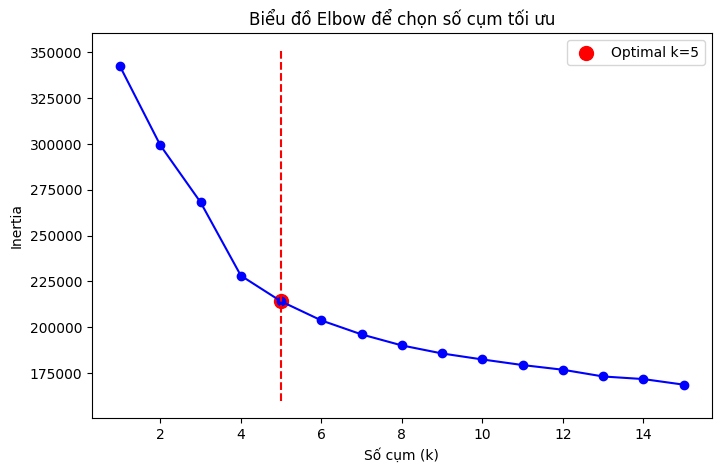

✅ Số cụm tối ưu được xác định: 5
📊 Đang phân cụm khách hàng với 5 cụm...


ValueError: too many values to unpack (expected 2)

In [ ]:
import warnings
import gspread
from google.colab import drive
from gspread_dataframe import set_with_dataframe
from google.colab import auth
from google.auth import default
import pandas as pd

# Cấu hình:
warnings.filterwarnings('ignore')
drive.mount('/content/drive')

# Google Authentication:
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# Hàm xuất kết quả ra Google Sheets
def export_to_google_sheet(data, sheet_name='Ket_qua_phan_khach_hang'):
    # Tạo Google Sheet mới
    sh = gc.create(sheet_name)

    # Thêm worksheet chi tiết các đơn hàng
    worksheet1 = sh.add_worksheet(title='Chi_tiet_cac_don_hang', rows=data.shape[0]+1, cols=data.shape[1]+1)
    set_with_dataframe(worksheet1, data)

    print(f"✅ Đã xuất kết quả lên Google Sheet: {sh.url}")

# Sau khi thực hiện phân cụm và phân tích
def main():
    print("🔄 Đang tiền xử lý dữ liệu...")
    processed_data = preprocess_data(df)

    print("🔍 Đang tìm số cụm tối ưu...")
    optimal_k = find_optimal_clusters(processed_data)

    print(f"📊 Đang phân cụm khách hàng với {optimal_k} cụm...")
    clustered_data, model = perform_clustering(processed_data, n_clusters=optimal_k)

    print("🔍 Phân tích kết quả phân cụm...")
    analyze_clusters(clustered_data)

    # Xuất kết quả phân cụm ra Google Sheets
    export_to_google_sheet(clustered_data)

    return clustered_data

# Gọi hàm chính
final_result = main()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/My Drive')

['The_Development_of_Performance_Dashboard.pdf',
 'The_Development_of_Performance_Dashboard.gdoc',
 'Bản dịch của The_Development_of_Performance_Dashboard.gdoc',
 'Dũng_BTCN',
 'Microsoft Power BI.gdoc',
 'Case03-Remarkable turnaround.pdf',
 'Case03-Remarkable turnaround.gdoc',
 'Bản dịch của Case03-Remarkable turnaround.gdoc',
 'Trần Tiến Dũng_2470066_BT3.1.drawio',
 'Trần Tiến Dũng_2470066_BT3.2.drawio',
 'TranTien Dung_2470066_BT3.22 (4).drawio',
 'BT1.drawio',
 'bpmn_process.drawio',
 'Colab Notebooks',
 'BT 9.3 & 9.5.gdoc',
 'Project B.drawio',
 '2470066.drawio',
 'BT NHÓM: QUẢN LÝ VÀ LÃNH ĐẠO.gdoc',
 'ClusteredDrivers (1).gsheet',
 'Random forest.gsheet',
 'ClusteredDrivers.gsheet',
 'RandomForest (1).gsheet',
 'RandomForest.gsheet',
 'RandomForest_Result (2).gsheet',
 'RandomForest_Result (1).gsheet',
 'RandomForest_Result.gsheet',
 'Ket_qua_phan_khach_hang (2).gsheet',
 'Ket_qua_phan_khach_hang (1).gsheet',
 'Ket_qua_phan_khach_hang.gsheet']

In [ ]:
import os

os.path.exists('/content/drive/My Drive/Colab Notebooks/Zomato Dataset.xlsx')

True